# Full Imagery Model Feature Sweep

## tl;dr

This notebook compares the full `Data_Pattern/patt` 6x6 reconstruction sweep over the mixed `geometric+random` corpus. It reads immutable Stage 3 classical artifacts and Stage 4 Torch artifacts through safe metadata/array loaders, writes `stage5_comparison_summary.json`, and keeps Cross-subject and Within-subject results separate.

The paired intervals below use subject-cluster bootstrap draws against the canonical `logistic-regression-independent/lbp` reference inside each protocol. They are exploratory pointwise intervals, not multiplicity-adjusted, so descriptive leaders are thesis discussion candidates rather than proof of superiority.

## Data And Coverage

The sweep covers the full pattern corpus: 540 `patt` samples, 360 geometric targets and 180 random targets. Deterministic geometric image repeats are tracked as task-label provenance; random image fingerprint, random seed, sample-key, and protocol-boundary overlaps remain forbidden leakage.

Classical coverage comes from 10 model IDs crossed with 9 fixed feature families and 2 protocols. Torch coverage comes from 3 architectures crossed with 4 spectral methods and 2 protocols. Failed classical convergence cases are carried forward explicitly instead of being silently dropped.

In [1]:
from __future__ import annotations

from pathlib import Path
import os

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
import pandas as pd

from experiments.random_imagery.full_sweep_comparison import (
    FULL_IMAGERY_COMPARISON_SUMMARY_PATH,
    FULL_IMAGERY_FIGURE_DIR,
    validate_full_imagery_comparison_summary,
    write_full_imagery_comparison_summary,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 130, "font.size": 9})

SUMMARY_PATH = FULL_IMAGERY_COMPARISON_SUMMARY_PATH
FIGURE_DIR = FULL_IMAGERY_FIGURE_DIR
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary = write_full_imagery_comparison_summary(
    output_path=SUMMARY_PATH,
    n_resamples=2_000,
    random_state=42,
    confidence_level=0.95,
)
validate_full_imagery_comparison_summary(summary)
summary["coverage"]

{'classical': {'planned_protocol_run_count': 180,
  'completed_protocol_run_count': 167,
  'completed_direction_run_count': 249,
  'failed_protocol_run_count': 13},
 'torch': {'planned_protocol_run_count': 24,
  'completed_protocol_run_count': 24,
  'completed_direction_run_count': 36,
  'failed_protocol_run_count': 0},
 'completed_learned_condition_count': 191,
 'completed_direction_run_count': 285,
 'failed_protocol_run_count': 13}

In [2]:
def learned_frame(protocol: str) -> pd.DataFrame:
    rows = []
    for item in summary["protocol_summaries"][protocol]["learned_runs"]:
        metrics = item["metrics"]
        ci = item["mean_balanced_accuracy_ci"]
        delta = item["delta_vs_reference"]
        rows.append({
            "protocol": protocol,
            "family": item["model_family"],
            "model_id": item["model_id"],
            "condition": item["feature_slug"] or item["method"],
            "architecture": item["architecture"],
            "mean_balanced_accuracy": metrics["mean_balanced_accuracy"],
            "ba_ci_lower": ci["lower"],
            "ba_ci_upper": ci["upper"],
            "delta_vs_logreg_lbp": delta["mean_balanced_accuracy"],
            "delta_ci_lower": delta["ci_lower"],
            "delta_ci_upper": delta["ci_upper"],
            "mean_macro_f1": metrics["mean_macro_f1"],
            "bit_accuracy": metrics["bit_accuracy"],
            "exact_match_accuracy": metrics["exact_match_accuracy"],
            "hamming_loss": metrics["hamming_loss"],
            "run_key": item["run_key"],
        })
    return pd.DataFrame(rows)

def baseline_frame(protocol: str) -> pd.DataFrame:
    rows = []
    for item in summary["protocol_summaries"][protocol]["baseline_rows"]:
        metrics = item["metrics"]
        ci = item["mean_balanced_accuracy_ci"]
        delta = item["delta_vs_reference"]
        rows.append({
            "protocol": protocol,
            "baseline": item["baseline_name"],
            "mean_balanced_accuracy": metrics["mean_balanced_accuracy"],
            "ba_ci_lower": ci["lower"],
            "ba_ci_upper": ci["upper"],
            "delta_vs_logreg_lbp": delta["mean_balanced_accuracy"],
            "delta_ci_lower": delta["ci_lower"],
            "delta_ci_upper": delta["ci_upper"],
            "bit_accuracy": metrics["bit_accuracy"],
            "hamming_loss": metrics["hamming_loss"],
        })
    return pd.DataFrame(rows)

learned = pd.concat([learned_frame("cross-subject"), learned_frame("within-subject")], ignore_index=True)
baselines = pd.concat([baseline_frame("cross-subject"), baseline_frame("within-subject")], ignore_index=True)

coverage_rows = []
for family in ("classical", "torch"):
    coverage = summary["coverage"][family]
    coverage_rows.append({"family": family, **coverage})
pd.DataFrame(coverage_rows)

,family,planned_protocol_run_count,completed_protocol_run_count,completed_direction_run_count,failed_protocol_run_count
0,classical,180,167,249,13
1,torch,24,24,36,0


## Protocol-Separated Leaders

Cross-subject and Within-subject answer different questions, so they stay in separate tables and figures. The ranking key is mean balanced accuracy over the 36 binary pixels. Exact-match accuracy is expected to be very low because a full 6x6 image must be exactly correct.

In [3]:
leader_columns = [
    "family",
    "model_id",
    "condition",
    "architecture",
    "mean_balanced_accuracy",
    "ba_ci_lower",
    "ba_ci_upper",
    "delta_vs_logreg_lbp",
    "delta_ci_lower",
    "delta_ci_upper",
    "bit_accuracy",
    "exact_match_accuracy",
]

cross_top = learned[learned["protocol"] == "cross-subject"].head(12)[leader_columns]
within_top = learned[learned["protocol"] == "within-subject"].head(12)[leader_columns]
print("Cross-subject")
display(cross_top)
print("Within-subject")
display(within_top)

Cross-subject


,family,model_id,condition,architecture,mean_balanced_accuracy,ba_ci_lower,ba_ci_upper,delta_vs_logreg_lbp,delta_ci_lower,delta_ci_upper,bit_accuracy,exact_match_accuracy
0,torch,eegnet-stft-multilabel,stft,eegnet,0.525845,0.497681,0.556626,0.036915,0.005357,0.067819,0.550332,0.017094
1,classical,random-forest-independent,time+spectral,NaN,0.517276,0.507890,0.526139,0.028346,0.012640,0.043998,0.585470,0.000000
2,torch,eegnet-superlet-multilabel,superlet,eegnet,0.516823,0.501814,0.531940,0.027893,0.005267,0.048423,0.557692,0.000000
3,classical,elastic-net-multioutput,log_covariance,NaN,0.515018,0.501052,0.528080,0.026088,0.004611,0.043226,0.565052,0.000000
4,classical,ridge-regression-multioutput,log_covariance,NaN,0.514917,0.500560,0.528174,0.025987,0.005235,0.043295,0.564577,0.000000
5,classical,logistic-regression-independent,covariance,NaN,0.514222,0.499429,0.527315,0.025293,0.001971,0.045862,0.542498,0.000000
6,classical,random-forest-multioutput,time,NaN,0.513392,0.504359,0.519946,0.024463,0.008402,0.037342,0.616097,0.000000
7,classical,pls-regression-multioutput,log_covariance,NaN,0.513321,0.498332,0.526195,0.024391,0.010242,0.032645,0.589981,0.000000
8,classical,pls-regression-multioutput,time,NaN,0.513304,0.503577,0.524073,0.024374,0.012417,0.032745,0.605651,0.025641
9,torch,eegnet-morlet-multilabel,morlet,eegnet,0.513022,0.491534,0.534227,0.024092,-0.005313,0.046400,0.519231,0.000000


Within-subject


,family,model_id,condition,architecture,mean_balanced_accuracy,ba_ci_lower,ba_ci_upper,delta_vs_logreg_lbp,delta_ci_lower,delta_ci_upper,bit_accuracy,exact_match_accuracy
97,classical,pls-regression-multioutput,lgp,NaN,0.511556,0.501478,0.521404,0.015269,0.001203,0.028341,0.581333,0.008230
98,torch,deep-convnet-superlet-multilabel,superlet,deep-convnet,0.509403,0.500122,0.517877,0.013116,0.001507,0.024150,0.497542,0.000000
99,classical,ridge-regression-independent,lgp,NaN,0.509206,0.500165,0.518193,0.012918,0.003552,0.023381,0.551097,0.000000
100,classical,elastic-net-multioutput,lgp,NaN,0.506820,0.497356,0.515278,0.010533,-0.002078,0.021823,0.567273,0.002058
101,torch,eegnet-morlet-multilabel,morlet,eegnet,0.506726,0.498727,0.514665,0.010439,0.000027,0.020578,0.511203,0.000000
102,classical,logistic-regression-independent,lgp,NaN,0.506309,0.498223,0.513556,0.010022,-0.000789,0.020586,0.536123,0.000000
103,classical,random-forest-multioutput,lgp,NaN,0.505766,0.499718,0.511959,0.009479,-0.000701,0.019486,0.601223,0.000000
104,classical,elastic-net-independent,lgp,NaN,0.504697,0.497426,0.511923,0.008410,-0.001674,0.018960,0.562929,0.000000
105,classical,ridge-regression-multioutput,lgp,NaN,0.503983,0.493820,0.513176,0.007695,-0.005852,0.020633,0.556927,0.002058
106,torch,eegnet-stft-multilabel,stft,eegnet,0.502624,0.486516,0.516993,0.006337,-0.007890,0.020741,0.521376,0.000000


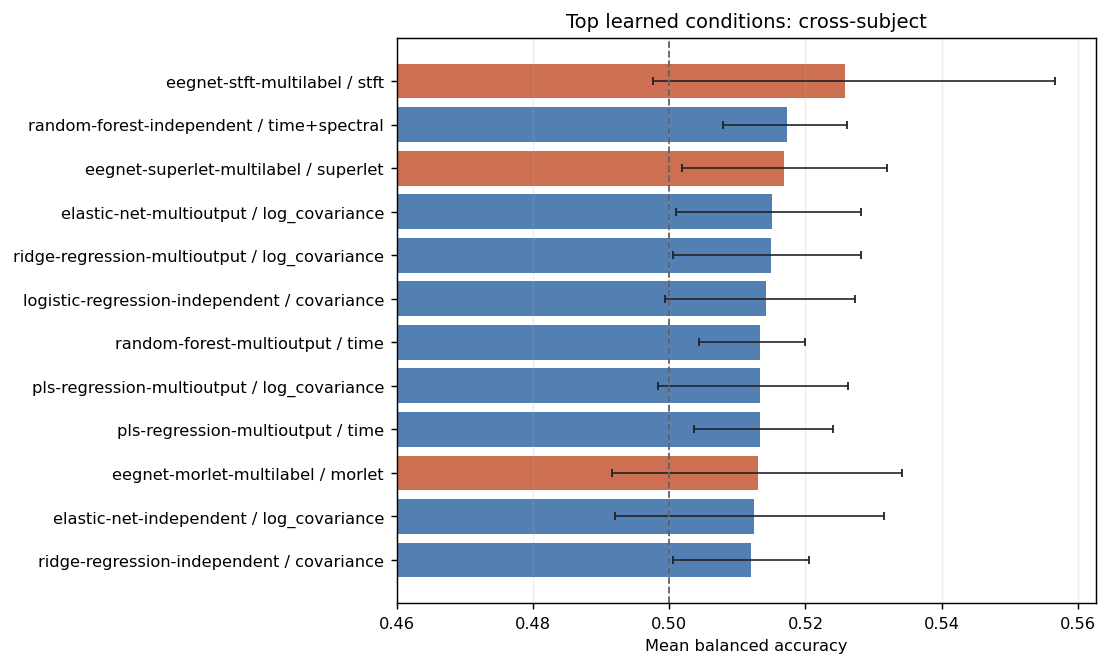

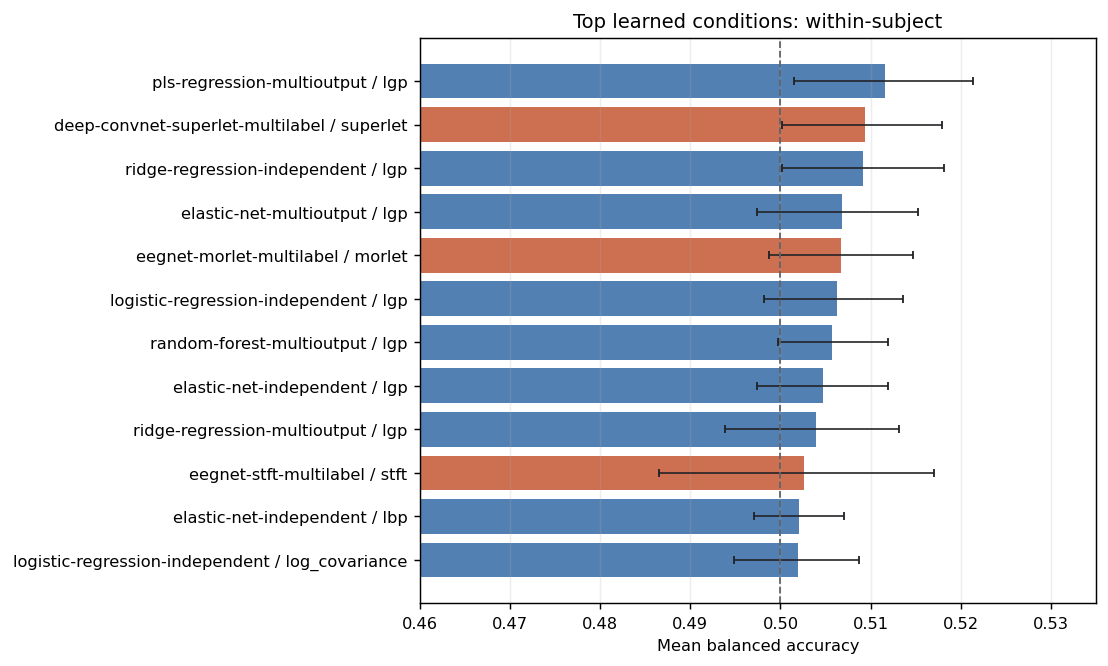

In [4]:
def plot_top(protocol: str, path: Path) -> None:
    frame = learned[learned["protocol"] == protocol].head(12).copy().iloc[::-1]
    labels = frame["model_id"] + " / " + frame["condition"].fillna("")
    colors = frame["family"].map({"classical": "#3b6ea8", "torch": "#c75b39"})
    x = frame["mean_balanced_accuracy"]
    lower = x - frame["ba_ci_lower"]
    upper = frame["ba_ci_upper"] - x
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    ax.barh(labels, x, color=colors, alpha=0.88)
    ax.errorbar(x, labels, xerr=[lower, upper], fmt="none", color="#202124", linewidth=0.9, capsize=2)
    ax.axvline(0.5, color="#5f6368", linestyle="--", linewidth=1)
    ax.set_xlabel("Mean balanced accuracy")
    ax.set_title(f"Top learned conditions: {protocol}")
    ax.set_xlim(0.46, max(0.535, float(frame["ba_ci_upper"].max()) + 0.006))
    ax.grid(axis="x", alpha=0.22)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()

plot_top("cross-subject", FIGURE_DIR / "cross_subject_top_learned.png")
plot_top("within-subject", FIGURE_DIR / "within_subject_top_learned.png")

## Paired Subject-Cluster Bootstrap

Every learned condition is compared only after confirming identical ordered test sample keys, targets, and subject IDs against the protocol reference. The paired deltas below are against `logistic-regression-independent/lbp` within the same protocol. Intervals crossing zero are especially important here: the apparent rank differences are small and not multiplicity-adjusted.

In [5]:
paired_columns = [
    "family",
    "model_id",
    "condition",
    "mean_balanced_accuracy",
    "delta_vs_logreg_lbp",
    "delta_ci_lower",
    "delta_ci_upper",
]
for protocol in ("cross-subject", "within-subject"):
    print(protocol)
    display(learned[learned["protocol"] == protocol].head(15)[paired_columns])
    print(summary["protocol_summaries"][protocol]["interpretation"])

cross-subject


,family,model_id,condition,mean_balanced_accuracy,delta_vs_logreg_lbp,delta_ci_lower,delta_ci_upper
0,torch,eegnet-stft-multilabel,stft,0.525845,0.036915,0.005357,0.067819
1,classical,random-forest-independent,time+spectral,0.517276,0.028346,0.012640,0.043998
2,torch,eegnet-superlet-multilabel,superlet,0.516823,0.027893,0.005267,0.048423
3,classical,elastic-net-multioutput,log_covariance,0.515018,0.026088,0.004611,0.043226
4,classical,ridge-regression-multioutput,log_covariance,0.514917,0.025987,0.005235,0.043295
5,classical,logistic-regression-independent,covariance,0.514222,0.025293,0.001971,0.045862
6,classical,random-forest-multioutput,time,0.513392,0.024463,0.008402,0.037342
7,classical,pls-regression-multioutput,log_covariance,0.513321,0.024391,0.010242,0.032645
8,classical,pls-regression-multioutput,time,0.513304,0.024374,0.012417,0.032745
9,torch,eegnet-morlet-multilabel,morlet,0.513022,0.024092,-0.005313,0.046400


Best descriptive cross-subject condition is torch:eegnet-stft-multilabel:stft:cross-subject with mean balanced accuracy 0.525845; pointwise paired delta vs classical:logistic-regression-independent:lbp:cross-subject is 0.036915 [0.005357, 0.067819].
within-subject


,family,model_id,condition,mean_balanced_accuracy,delta_vs_logreg_lbp,delta_ci_lower,delta_ci_upper
97,classical,pls-regression-multioutput,lgp,0.511556,0.015269,0.001203,0.028341
98,torch,deep-convnet-superlet-multilabel,superlet,0.509403,0.013116,0.001507,0.024150
99,classical,ridge-regression-independent,lgp,0.509206,0.012918,0.003552,0.023381
100,classical,elastic-net-multioutput,lgp,0.506820,0.010533,-0.002078,0.021823
101,torch,eegnet-morlet-multilabel,morlet,0.506726,0.010439,0.000027,0.020578
102,classical,logistic-regression-independent,lgp,0.506309,0.010022,-0.000789,0.020586
103,classical,random-forest-multioutput,lgp,0.505766,0.009479,-0.000701,0.019486
104,classical,elastic-net-independent,lgp,0.504697,0.008410,-0.001674,0.018960
105,classical,ridge-regression-multioutput,lgp,0.503983,0.007695,-0.005852,0.020633
106,torch,eegnet-stft-multilabel,stft,0.502624,0.006337,-0.007890,0.020741


Best descriptive within-subject condition is classical:pls-regression-multioutput:lgp:within-subject with mean balanced accuracy 0.511556; pointwise paired delta vs classical:logistic-regression-independent:lbp:within-subject is 0.015269 [0.001203, 0.028341].


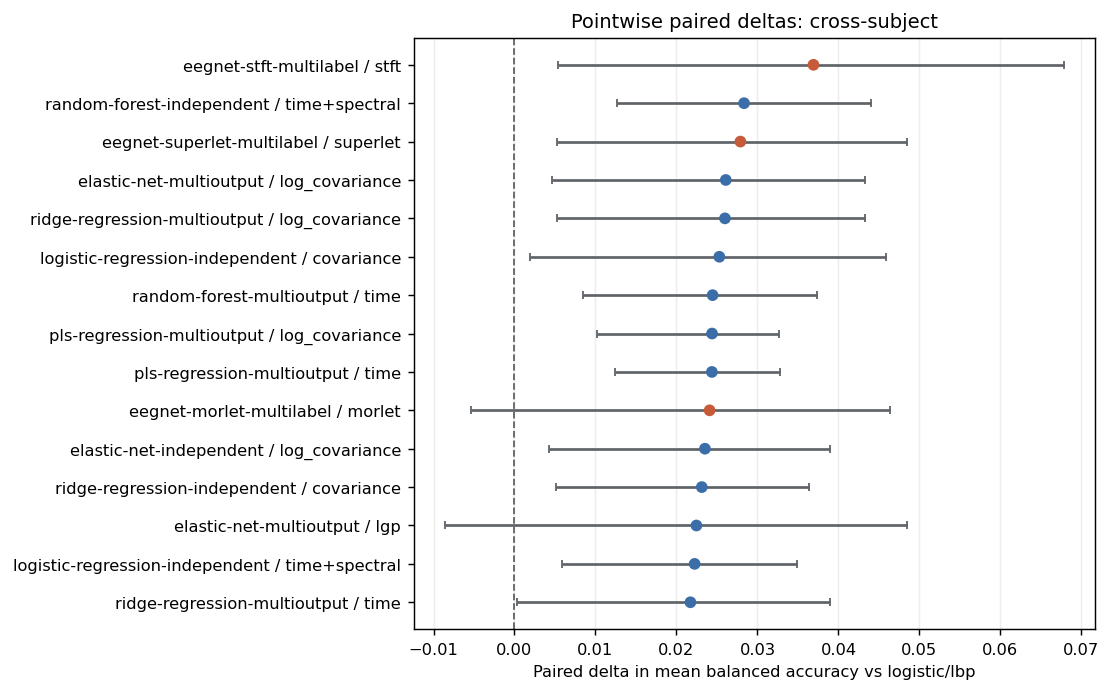

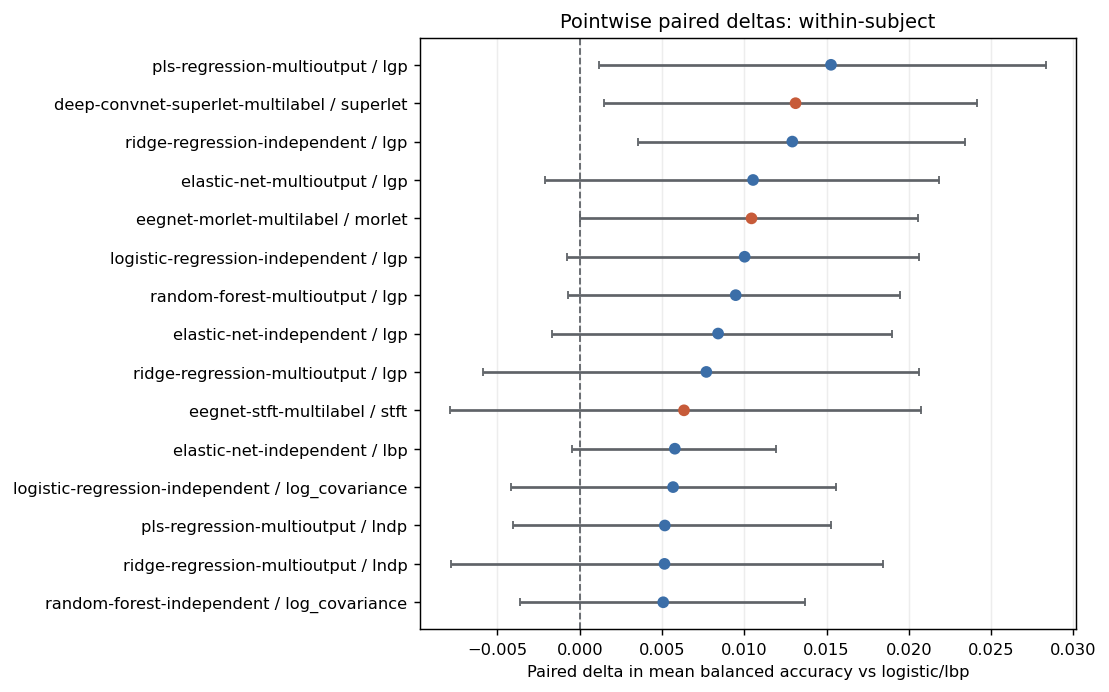

In [6]:
def plot_delta(protocol: str, path: Path) -> None:
    frame = learned[learned["protocol"] == protocol].head(15).copy().iloc[::-1]
    labels = frame["model_id"] + " / " + frame["condition"].fillna("")
    x = frame["delta_vs_logreg_lbp"]
    lower = x - frame["delta_ci_lower"]
    upper = frame["delta_ci_upper"] - x
    colors = frame["family"].map({"classical": "#3b6ea8", "torch": "#c75b39"})
    fig, ax = plt.subplots(figsize=(8.6, 5.4))
    ax.errorbar(x, labels, xerr=[lower, upper], fmt="o", color="#202124", ecolor="#5f6368", capsize=2, markersize=3)
    ax.scatter(x, labels, c=colors, s=30, zorder=3)
    ax.axvline(0.0, color="#5f6368", linestyle="--", linewidth=1)
    ax.set_xlabel("Paired delta in mean balanced accuracy vs logistic/lbp")
    ax.set_title(f"Pointwise paired deltas: {protocol}")
    ax.grid(axis="x", alpha=0.22)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()

plot_delta("cross-subject", FIGURE_DIR / "cross_subject_paired_delta_vs_logreg_lbp.png")
plot_delta("within-subject", FIGURE_DIR / "within_subject_paired_delta_vs_logreg_lbp.png")

## Feature And Method Families

For classical models, `condition` is the fixed feature family. For Torch models, `condition` is the spectral representation. These aggregates are descriptive: they mix model classes within a family and should be used for orientation, not as causal evidence about a feature extractor.

,protocol,family,condition,n_conditions,mean_ba,median_ba,max_ba
8,cross-subject,classical,time+spectral,10,0.506852,0.505850,0.517276
5,cross-subject,classical,log_covariance,10,0.507784,0.507326,0.515018
1,cross-subject,classical,covariance,7,0.502141,0.500513,0.514222
7,cross-subject,classical,time,8,0.506270,0.503660,0.513392
3,cross-subject,classical,lgp,10,0.500997,0.501742,0.511393
0,cross-subject,classical,correlation,10,0.496478,0.498690,0.508565
6,cross-subject,classical,spectral,10,0.498996,0.499744,0.507046
4,cross-subject,classical,lndp,10,0.502593,0.502133,0.506474
2,cross-subject,classical,lbp,10,0.497171,0.498468,0.504597
11,cross-subject,torch,stft,3,0.507880,0.505721,0.525845


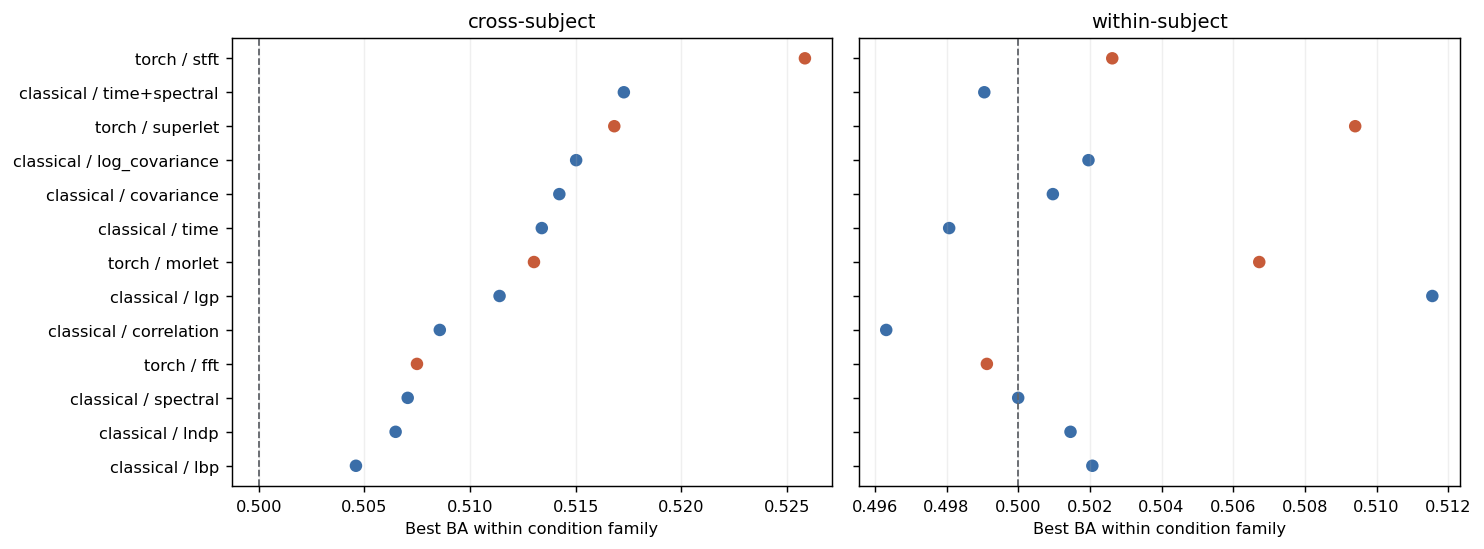

In [7]:
feature_summary = (
    learned.groupby(["protocol", "family", "condition"], dropna=False)
    .agg(
        n_conditions=("run_key", "count"),
        mean_ba=("mean_balanced_accuracy", "mean"),
        median_ba=("mean_balanced_accuracy", "median"),
        max_ba=("mean_balanced_accuracy", "max"),
    )
    .reset_index()
    .sort_values(["protocol", "family", "max_ba"], ascending=[True, True, False])
)
display(feature_summary)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
for ax, protocol in zip(axes, ("cross-subject", "within-subject"), strict=True):
    frame = feature_summary[feature_summary["protocol"] == protocol].copy()
    frame["label"] = frame["family"] + " / " + frame["condition"]
    frame = frame.sort_values("max_ba")
    ax.scatter(frame["max_ba"], frame["label"], c=frame["family"].map({"classical": "#3b6ea8", "torch": "#c75b39"}), s=35)
    ax.axvline(0.5, color="#5f6368", linestyle="--", linewidth=1)
    ax.set_title(protocol)
    ax.set_xlabel("Best BA within condition family")
    ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "feature_method_family_maxima.png", bbox_inches="tight")
plt.show()

## Baselines

The non-EEG baselines are read from the same protocol reference artifacts. They are useful sanity checks: a learned condition that does not clearly separate from these baselines is not strong evidence for recoverable EEG signal.

,protocol,baseline,mean_balanced_accuracy,ba_ci_lower,ba_ci_upper,delta_vs_logreg_lbp,delta_ci_lower,delta_ci_upper,bit_accuracy,hamming_loss
2,cross-subject,seeded_bernoulli,0.500725,0.490257,0.511824,0.011795,-0.005359,0.025876,0.528490,0.471510
0,cross-subject,global_majority,0.500000,0.500000,0.500000,0.011070,-0.000240,0.019614,0.575499,0.424501
1,cross-subject,pixel_frequency,0.500000,0.500000,0.500000,0.011070,-0.000240,0.019614,0.617521,0.382479
5,within-subject,seeded_bernoulli,0.500892,0.491977,0.510058,0.004605,-0.006658,0.016258,0.531779,0.468221
3,within-subject,global_majority,0.500000,0.500000,0.500000,0.003713,-0.003400,0.010861,0.578361,0.421639
4,within-subject,pixel_frequency,0.498399,0.496912,0.499888,0.002111,-0.005421,0.009784,0.609225,0.390775


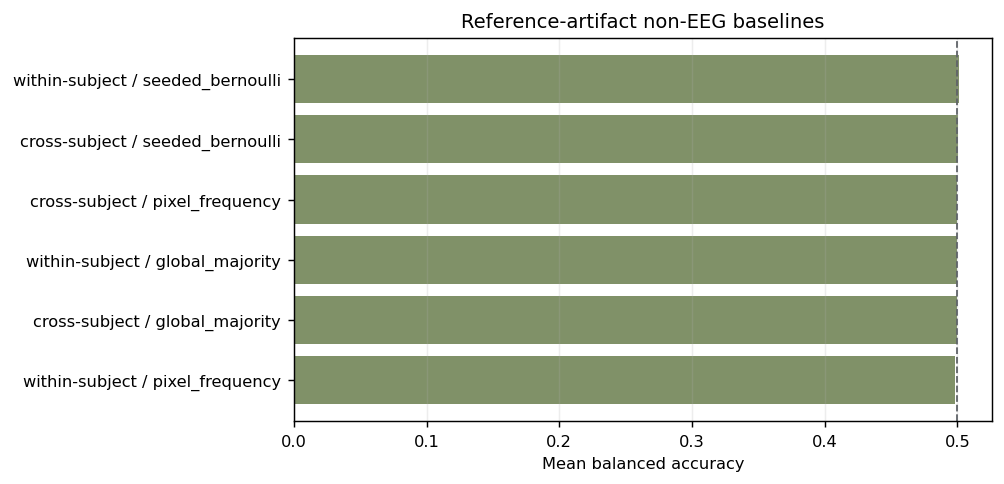

In [8]:
display(baselines.sort_values(["protocol", "mean_balanced_accuracy"], ascending=[True, False]))

fig, ax = plt.subplots(figsize=(7.8, 3.8))
plot_frame = baselines.copy()
plot_frame["label"] = plot_frame["protocol"] + " / " + plot_frame["baseline"]
plot_frame = plot_frame.sort_values("mean_balanced_accuracy")
ax.barh(plot_frame["label"], plot_frame["mean_balanced_accuracy"], color="#6b7f4f", alpha=0.86)
ax.axvline(0.5, color="#5f6368", linestyle="--", linewidth=1)
ax.set_xlabel("Mean balanced accuracy")
ax.set_title("Reference-artifact non-EEG baselines")
ax.grid(axis="x", alpha=0.22)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "reference_baselines.png", bbox_inches="tight")
plt.show()

## Limitations

- The intervals are paired and subject-clustered, but not multiplicity-adjusted. Treat them as pointwise uncertainty for ranking diagnostics.
- Classical regression scores are clipped regression outputs, not probabilities. Score MSE is therefore a calibration-style diagnostic, not a probability-quality claim.
- We never average cross-subject and within-subject results; they answer different generalization questions.
- The full corpus intentionally includes repeated deterministic geometric task labels. Random-image fingerprint overlap remains forbidden leakage.
- Most descriptive leaders are close to chance-level balanced accuracy, so thesis claims should emphasize weak effects, uncertainty, and protocol validity over model wins.

In [9]:
print(f"summary: {SUMMARY_PATH}")
print(f"figures: {FIGURE_DIR}")
print("FULL_IMAGERY_SWEEP_COMPARISON_VERIFIED")

summary: artifacts/experiments/full-imagery/stage5_comparison_summary.json
figures: artifacts/experiments/full-imagery/stage5_figures
FULL_IMAGERY_SWEEP_COMPARISON_VERIFIED
